# Questão 7 - Equações Diferenciais Parciais Elípticas (Algoritmo 12.1)

Obtenha aproximações para as soluções das equações diferenciais parciais elípticas seguintes, utilizando o Algoritmo 12.1:

## Letra a)

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0, \quad 0 < x < 1, \quad 0 < y < 1$$

**Condições de contorno:**

$$u(x,0) = 0, \quad u(x,1) = x, \quad 0 \leq x \leq 1$$

$$u(0,y) = 0, \quad u(1,y) = y, \quad 0 \leq y \leq 1$$

Use $h = k = 0,2$ e compare os resultados com a solução real:

$$u(x,y) = xy$$

## Letra b)

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = -(\cos(x+y) + \cos(x-y)), \quad 0 < x < \pi, \quad 0 < y < \frac{\pi}{2}$$

**Condições de contorno:**

$$u(0,y) = \cos y, \quad u(\pi,y) = -\cos y, \quad 0 \leq y \leq \frac{\pi}{2}$$

$$u(x,0) = \cos x, \quad u\left(x,\frac{\pi}{2}\right) = 0, \quad 0 \leq x \leq \pi$$

Use $h = \pi/5$ e $k = \pi/10$ e compare os resultados com a solução real:

$$u(x,y) = \cos x \cos y$$

## Letra c)

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = (x^2 + y^2)e^{xy}, \quad 0 < x < 2, \quad 0 < y < 1$$

**Condições de contorno:**

$$u(0,y) = 1, \quad u(2,y) = e^{2y}, \quad 0 \leq y \leq 1$$

$$u(x,0) = 1, \quad u(x,1) = e^x, \quad 0 \leq x \leq 2$$

Use $h = 0,2$ e $k = 0,1$ e compare os resultados com a solução real:

$$u(x,y) = e^{xy}$$

## Letra d)

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \frac{x}{y} + \frac{y}{x}, \quad 1 < x < 2, \quad 1 < y < 2$$

**Condições de contorno:**

$$u(x,1) = x \ln x, \quad u(x,2) = x \ln(4x^2), \quad 1 \leq x \leq 2$$

$$u(1,y) = y \ln y, \quad u(2,y) = 2y \ln(2y), \quad 1 \leq y \leq 2$$

Use $h = k = 0,1$ e compare os resultados com a solução real:

$$u(x,y) = xy \ln(xy)$$

QUESTÃO 7 - LETRA A
Convergência alcançada em 42 iterações

Letra A - u_xx + u_yy = 0
x		y		Aproximado		Real			Erro
0.20		0.20		0.0399999923		0.0400000000		0.0000000077
0.20		0.40		0.0799999899		0.0800000000		0.0000000101
0.20		0.60		0.1199999918		0.1200000000		0.0000000082
0.20		0.80		0.1599999959		0.1600000000		0.0000000041
0.40		0.20		0.0799999899		0.0800000000		0.0000000101
0.40		0.40		0.1599999867		0.1600000000		0.0000000133
0.40		0.60		0.2399999893		0.2400000000		0.0000000107
0.40		0.80		0.3199999946		0.3200000000		0.0000000054
0.60		0.20		0.1199999918		0.1200000000		0.0000000082
0.60		0.40		0.2399999893		0.2400000000		0.0000000107
0.60		0.60		0.3599999913		0.3600000000		0.0000000087
0.60		0.80		0.4799999957		0.4800000000		0.0000000043
0.80		0.20		0.1599999959		0.1600000000		0.0000000041
0.80		0.40		0.3199999946		0.3200000000		0.0000000054
0.80		0.60		0.4799999957		0.4800000000		0.0000000043
0.80		0.80		0.6399999978		0.6400000000		0.0000000022
QUESTÃO 7 - LETRA B
Convergência alc

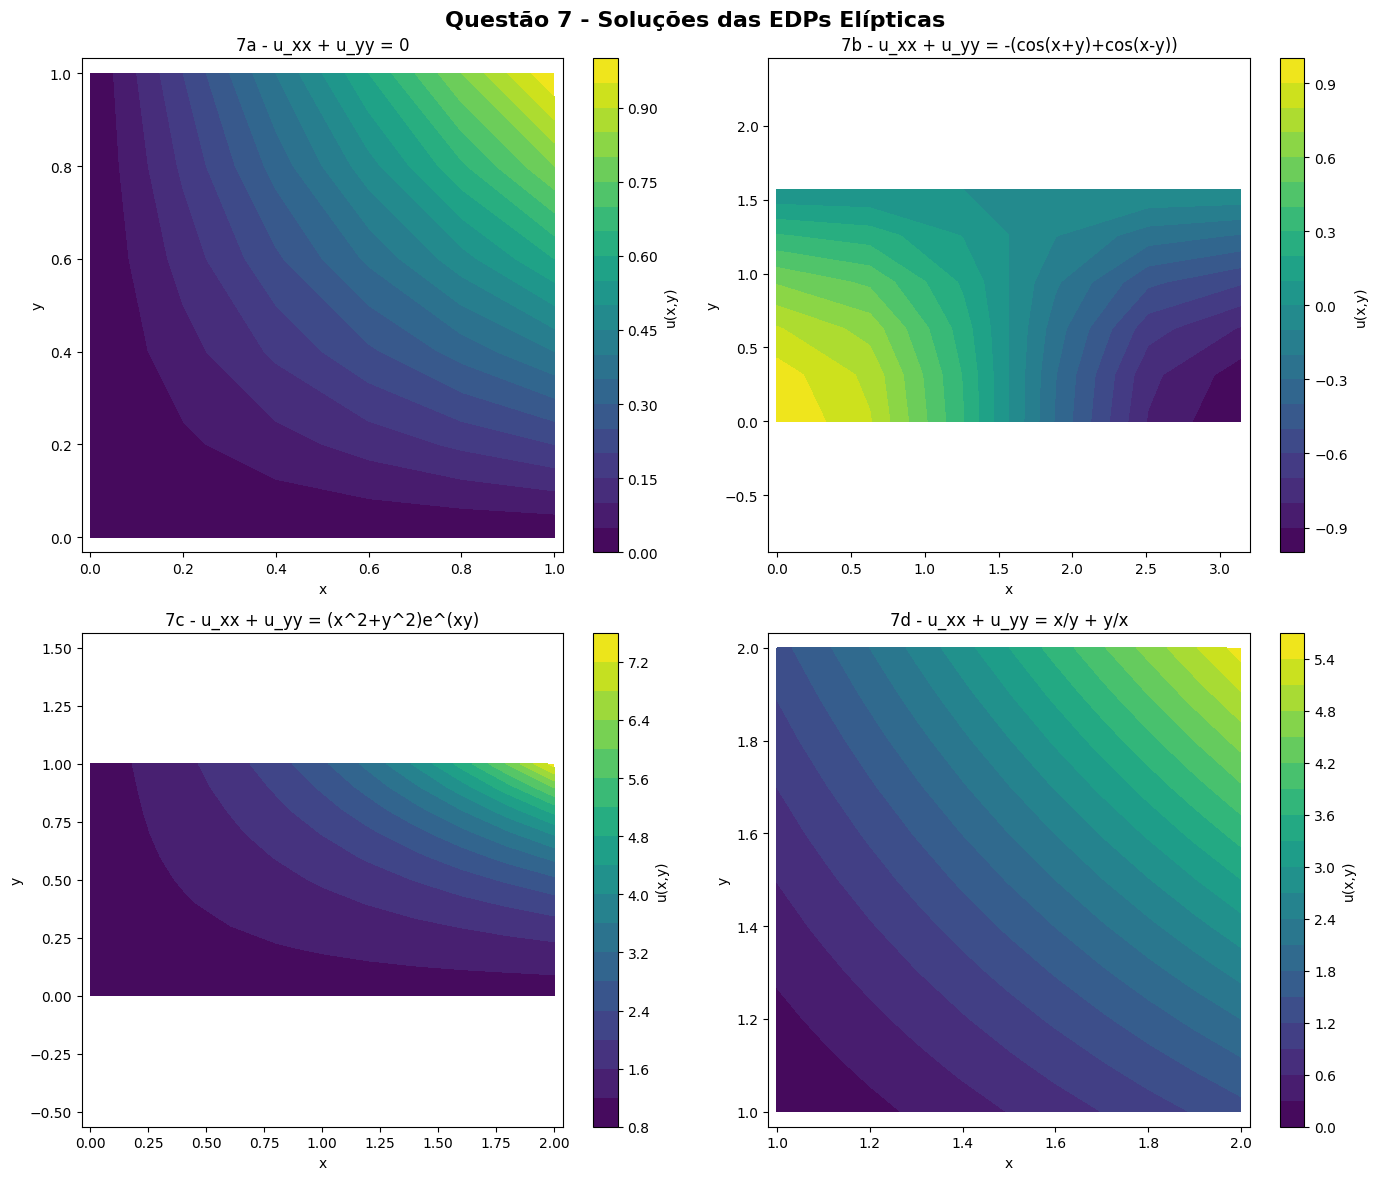

Convergência alcançada em 42 iterações
Convergência alcançada em 39 iterações
Convergência alcançada em 174 iterações
Convergência alcançada em 175 iterações


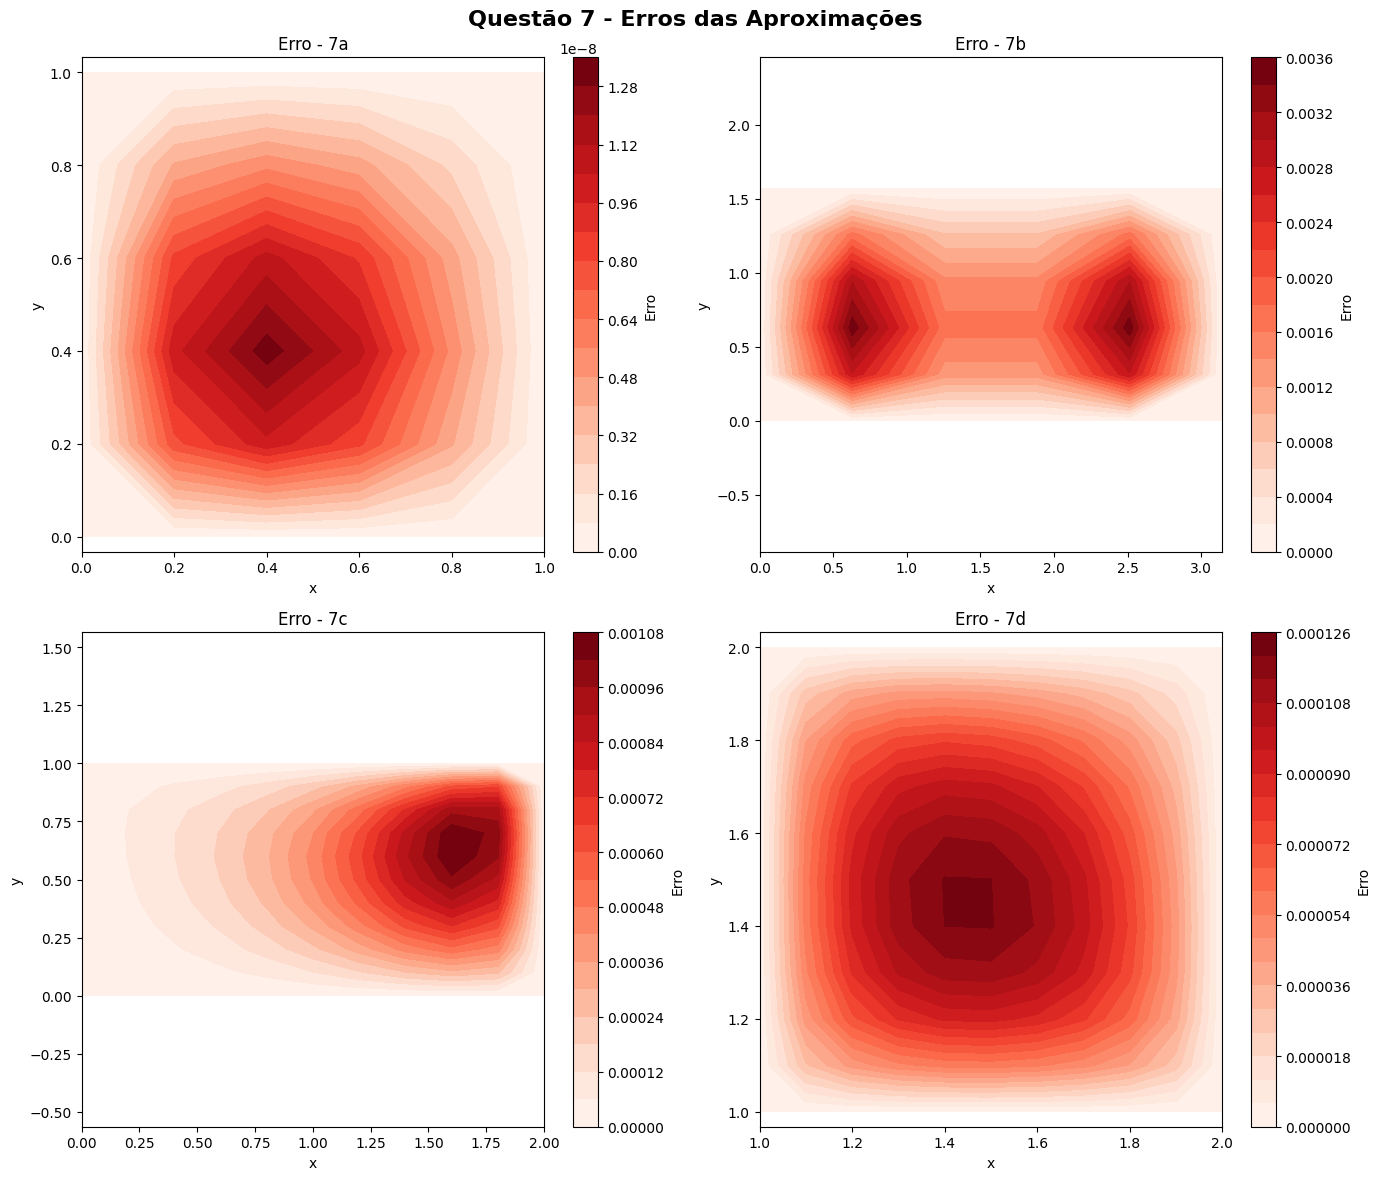

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def poisson_solver(f, x0, xf, y0, yf, h, k, boundary_func, max_iter=10000, tol=1e-8):
    """
    Resolve a equação de Poisson: u_xx + u_yy = f(x,y)
    usando o método de diferenças finitas (Algoritmo 12.1) - Gauss-Seidel
    
    Parâmetros:
    f: função f(x,y) do lado direito
    x0, xf: limites em x
    y0, yf: limites em y
    h: passo em x
    k: passo em y
    boundary_func: função que retorna os valores de contorno
    max_iter: número máximo de iterações
    tol: tolerância para convergência
    
    Retorna:
    x: vetor de pontos em x
    y: vetor de pontos em y
    u: matriz com a solução aproximada
    """
    # Número de pontos
    nx = int((xf - x0) / h) + 1
    ny = int((yf - y0) / k) + 1
    
    # Malha
    x = np.linspace(x0, xf, nx)
    y = np.linspace(y0, yf, ny)
    
    # Matriz de solução
    u = np.zeros((nx, ny))
    
    # Condições de contorno
    for i in range(nx):
        for j in range(ny):
            u[i, j] = boundary_func(x[i], y[j], x0, xf, y0, yf)
    
    # Coeficientes
    h2 = h**2
    k2 = k**2
    coef = 2*(1/h2 + 1/k2)
    
    # Gauss-Seidel
    for it in range(max_iter):
        u_old = u.copy()
        
        # Pontos internos
        for i in range(1, nx-1):
            for j in range(1, ny-1):
                # (1/h^2)*(u_{i-1,j} + u_{i+1,j}) + (1/k^2)*(u_{i,j-1} + u_{i,j+1}) - 2*(1/h^2 + 1/k^2)*u_{i,j} = f(x_i, y_j)
                u[i, j] = ((u[i-1, j] + u[i+1, j])/h2 + (u[i, j-1] + u[i, j+1])/k2 - f(x[i], y[j])) / coef
        
        # Verifica convergência
        if np.max(np.abs(u - u_old)) < tol:
            print(f"Convergência alcançada em {it+1} iterações")
            break
    
    return x, y, u


def print_solution(x, y, u, u_real, title):
    """Imprime a solução comparando com a real"""
    print(f"\n{title}")
    
    print("x\t\ty\t\tAproximado\t\tReal\t\t\tErro")
   
    nx, ny = u.shape
    for i in range(nx):
        for j in range(ny):
            if (i == 0 or i == nx-1 or j == 0 or j == ny-1):
                continue  # Pula contornos
            erro = abs(u[i, j] - u_real(x[i], y[j]))
            print(f"{x[i]:.2f}\t\t{y[j]:.2f}\t\t{u[i, j]:.10f}\t\t{u_real(x[i], y[j]):.10f}\t\t{erro:.10f}")


# QUESTÃO 7 - LETRA A
# u_xx + u_yy = 0
# u(x,0) = 0, u(x,1) = x, u(0,y) = 0, u(1,y) = y
# Solução real: u(x,y) = xy

def f7a(x, y):
    return 0

def boundary7a(x, y, x0, xf, y0, yf):
    # Contorno inferior
    if y == y0:
        return 0
    # Contorno superior
    elif y == yf:
        return x
    # Contorno esquerdo
    elif x == x0:
        return 0
    # Contorno direito
    elif x == xf:
        return y
    else:
        return 0

def real7a(x, y):
    return x*y

print("QUESTÃO 7 - LETRA A")

x0, xf, y0, yf = 0, 1, 0, 1
h, k = 0.2, 0.2

x, y, u = poisson_solver(f7a, x0, xf, y0, yf, h, k, boundary7a)
print_solution(x, y, u, real7a, "Letra A - u_xx + u_yy = 0")


# QUESTÃO 7 - LETRA B
# u_xx + u_yy = -(cos(x+y) + cos(x-y))
# Solução real: u(x,y) = cos(x)*cos(y)

def f7b(x, y):
    return -(np.cos(x + y) + np.cos(x - y))

def boundary7b(x, y, x0, xf, y0, yf):
    # Contorno inferior
    if y == y0:
        return np.cos(x)
    # Contorno superior
    elif y == yf:
        return 0
    # Contorno esquerdo
    elif x == x0:
        return np.cos(y)
    # Contorno direito
    elif x == xf:
        return -np.cos(y)
    else:
        return 0

def real7b(x, y):
    return np.cos(x)*np.cos(y)


print("QUESTÃO 7 - LETRA B")

x0, xf, y0, yf = 0, np.pi, 0, np.pi/2
h = np.pi/5
k = np.pi/10

x, y, u = poisson_solver(f7b, x0, xf, y0, yf, h, k, boundary7b, max_iter=50000)
print_solution(x, y, u, real7b, "Letra B - u_xx + u_yy = -(cos(x+y) + cos(x-y))")

# QUESTÃO 7 - LETRA C
# u_xx + u_yy = (x^2 + y^2)*e^(xy)
# Solução real: u(x,y) = e^(xy)

def f7c(x, y):
    return (x**2 + y**2)*np.exp(x*y)

def boundary7c(x, y, x0, xf, y0, yf):
    # Contorno inferior
    if y == y0:
        return 1
    # Contorno superior
    elif y == yf:
        return np.exp(x)
    # Contorno esquerdo
    elif x == x0:
        return 1
    # Contorno direito
    elif x == xf:
        return np.exp(2*y)
    else:
        return 0

def real7c(x, y):
    return np.exp(x*y)

print("QUESTÃO 7 - LETRA C")

x0, xf, y0, yf = 0, 2, 0, 1
h, k = 0.2, 0.1

x, y, u = poisson_solver(f7c, x0, xf, y0, yf, h, k, boundary7c, max_iter=20000)
print_solution(x, y, u, real7c, "Letra C - u_xx + u_yy = (x^2 + y^2)*e^(xy)")


# QUESTÃO 7 - LETRA D
# u_xx + u_yy = x/y + y/x
# Solução real: u(x,y) = xy*ln(xy)

def f7d(x, y):
    return x/y + y/x

def boundary7d(x, y, x0, xf, y0, yf):
    # Contorno inferior
    if y == y0:
        return x*np.log(x)
    # Contorno superior
    elif y == yf:
        return x*np.log(4*x**2)
    # Contorno esquerdo
    elif x == x0:
        return y*np.log(y)
    # Contorno direito
    elif x == xf:
        return 2*y*np.log(2*y)
    else:
        return 0

def real7d(x, y):
    return x*y*np.log(x*y)


print("QUESTÃO 7 - LETRA D")


x0, xf, y0, yf = 1, 2, 1, 2
h, k = 0.1, 0.1

x, y, u = poisson_solver(f7d, x0, xf, y0, yf, h, k, boundary7d, max_iter=20000)
print_solution(x, y, u, real7d, "Letra D - u_xx + u_yy = x/y + y/x")

# GRÁFICOS

def plot_contour(x, y, u, title, subplot_pos):
    """Plota o gráfico de contorno da solução"""
    plt.subplot(2, 2, subplot_pos)
    X, Y = np.meshgrid(x, y)
    plt.contourf(X, Y, u.T, levels=20, cmap='viridis')
    plt.colorbar(label='u(x,y)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.axis('equal')

plt.figure(figsize=(14, 12))

# Letra A
x, y, u = poisson_solver(f7a, 0, 1, 0, 1, 0.2, 0.2, boundary7a)
plot_contour(x, y, u, '7a - u_xx + u_yy = 0', 1)

# Letra B
x, y, u = poisson_solver(f7b, 0, np.pi, 0, np.pi/2, np.pi/5, np.pi/10, boundary7b, max_iter=50000)
plot_contour(x, y, u, '7b - u_xx + u_yy = -(cos(x+y)+cos(x-y))', 2)

# Letra C
x, y, u = poisson_solver(f7c, 0, 2, 0, 1, 0.2, 0.1, boundary7c, max_iter=20000)
plot_contour(x, y, u, '7c - u_xx + u_yy = (x^2+y^2)e^(xy)', 3)

# Letra D
x, y, u = poisson_solver(f7d, 1, 2, 1, 2, 0.1, 0.1, boundary7d, max_iter=20000)
plot_contour(x, y, u, '7d - u_xx + u_yy = x/y + y/x', 4)

plt.suptitle('Questão 7 - Soluções das EDPs Elípticas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# GRÁFICOS DE ERROS


def plot_error(x, y, u, u_real, title, subplot_pos):
    """Plota o gráfico de erro da solução"""
    plt.subplot(2, 2, subplot_pos)
    X, Y = np.meshgrid(x, y)
    erro = np.abs(u.T - u_real(X, Y))
    plt.contourf(X, Y, erro, levels=20, cmap='Reds')
    plt.colorbar(label='Erro')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Erro - {title}')
    plt.axis('equal')

plt.figure(figsize=(14, 12))

# Erro Letra A
x, y, u = poisson_solver(f7a, 0, 1, 0, 1, 0.2, 0.2, boundary7a)
plot_error(x, y, u, real7a, '7a', 1)

# Erro Letra B
x, y, u = poisson_solver(f7b, 0, np.pi, 0, np.pi/2, np.pi/5, np.pi/10, boundary7b, max_iter=50000)
plot_error(x, y, u, real7b, '7b', 2)

# Erro Letra C
x, y, u = poisson_solver(f7c, 0, 2, 0, 1, 0.2, 0.1, boundary7c, max_iter=20000)
plot_error(x, y, u, real7c, '7c', 3)

# Erro Letra D
x, y, u = poisson_solver(f7d, 1, 2, 1, 2, 0.1, 0.1, boundary7d, max_iter=20000)
plot_error(x, y, u, real7d, '7d', 4)

plt.suptitle('Questão 7 - Erros das Aproximações', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()